# Phân tích tham số Canny Edge Detection

**Phụ trách:** TV5 — Parameter Experiment
**Mục tiêu:** Khảo sát trực quan ảnh hưởng của **Sigma** (Gaussian Blur) và
**Threshold** (Low/High) đến kết quả Canny Edge Detection, dựa trên các
module đã xây dựng: `src/experiments/parameter_experiment.py` và
`src/visualization/plot_comparison.py`.

Notebook này là bản trình bày trực quan, tương tác của cùng một pipeline
đã dùng trong script CLI (`src/scripts/run_experiments.py`) — dùng để
minh họa kết quả trong báo cáo hoặc thuyết trình.


## 1. Chuẩn bị môi trường

In [1]:
import sys
from pathlib import Path

# Thêm thư mục gốc của project vào sys.path để import được package src
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
%matplotlib inline

from src.experiments.parameter_experiment import (
    load_input_image,
    run_sigma_experiment,
    run_threshold_experiment,
    save_sigma_comparison_figure,
    save_results_table,
    summarize_sigma_trend,
    summarize_threshold_trend,
    DEFAULT_SIGMA_VALUES,
    DEFAULT_THRESHOLD_PAIRS,
)
from src.visualization.plot_comparison import (
    plot_sigma_trend_line,
    plot_threshold_trend_line,
)

# Cac module tren goi matplotlib.use("Agg") de chay duoc qua CLI khong can GUI.
# Trong notebook, can bat lai che do inline SAU KHI import de hien thi bieu do truc tiep.
%matplotlib inline

print("Da import thanh cong cac module TV5.")


Da import thanh cong cac module TV5.


## 2. Nạp ảnh đầu vào

Notebook sẽ tự động tìm ảnh trong `data/input/normal/`. Nếu thư mục này
chưa có ảnh thật, hàm `load_input_image()` sẽ tự tạo một ảnh mẫu tổng hợp
(hình khối cơ bản + nhiễu nhẹ) để đảm bảo notebook luôn chạy được, ngay
cả khi nhóm chưa bổ sung ảnh thật vào repo.


[INFO] Khong tim thay anh trong data/input/normal/. Tu dong tao anh mau tong hop de chay thi nghiem.
[INFO] Da luu anh mau tai: /home/claude/project/xylyanh_lab2.2-main/data/input/normal/sample_generated.jpg
Anh dau vao: sample_generated  |  kich thuoc: (400, 400, 3)


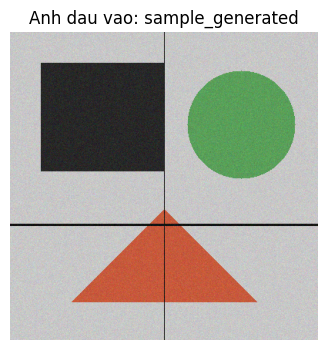

In [2]:
image, image_name = load_input_image()
print(f"Anh dau vao: {image_name}  |  kich thuoc: {image.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(image[:, :, ::-1])  # BGR -> RGB de hien thi dung mau
plt.title(f"Anh dau vao: {image_name}")
plt.axis("off")
plt.show()


## 3. Thí nghiệm 1 — Ảnh hưởng của Sigma

Cố định `Low Threshold = 100`, `High Threshold = 200`, thay đổi Sigma
qua các giá trị: `0.5, 1.0, 1.5, 2.0, 3.0`.


In [3]:
sigma_results = run_sigma_experiment(image, sigma_values=DEFAULT_SIGMA_VALUES)

for r in sigma_results:
    print(f"sigma={r['sigma']:<4} | edge_density={r['edge_density_percent']:>6}% "
          f"| time={r['processing_time_ms']:>6} ms")


sigma=0.5  | edge_density= 1.932% | time=  3.48 ms
sigma=1.0  | edge_density= 1.939% | time= 0.817 ms
sigma=1.5  | edge_density=   1.8% | time= 0.855 ms
sigma=2.0  | edge_density= 1.772% | time= 0.783 ms
sigma=3.0  | edge_density= 1.803% | time= 0.776 ms


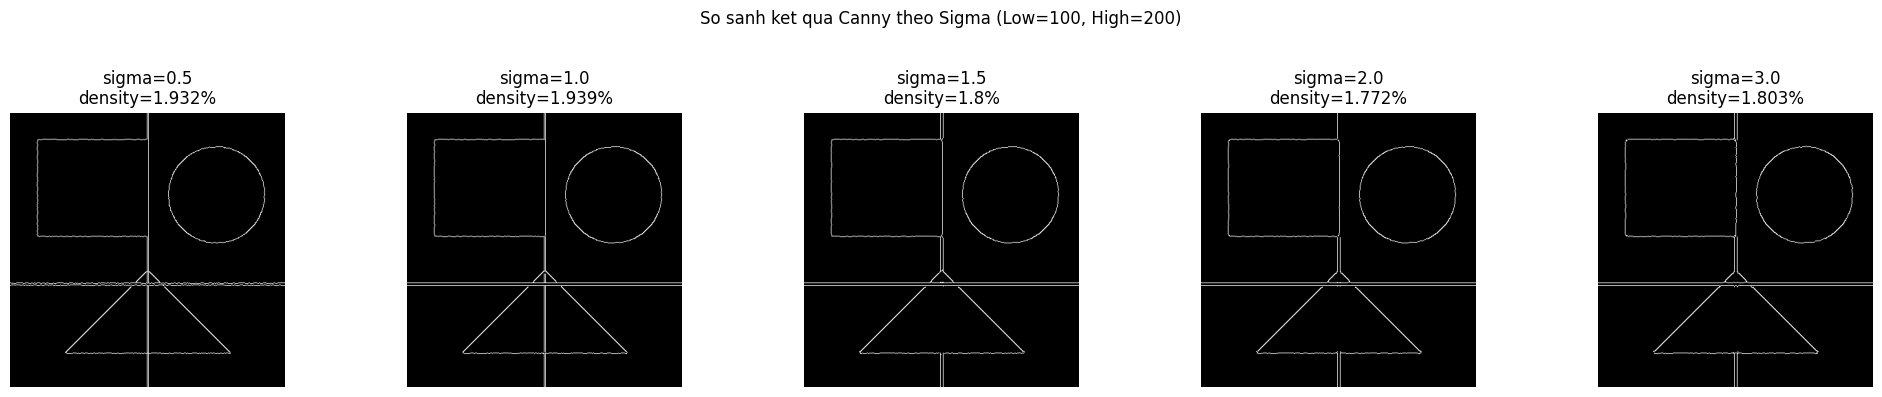

In [4]:
fig, axes = plt.subplots(1, len(sigma_results), figsize=(4 * len(sigma_results), 4))
for ax, r in zip(axes, sigma_results):
    ax.imshow(r["edges"], cmap="gray")
    ax.set_title(f"sigma={r['sigma']}\ndensity={r['edge_density_percent']}%")
    ax.axis("off")
fig.suptitle("So sanh ket qua Canny theo Sigma (Low=100, High=200)")
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


## 4. Thí nghiệm 2 — Ảnh hưởng của Threshold

Cố định `Sigma = 1.0`, thay đổi cặp `(Low, High)` Threshold qua các giá
trị: `(50,100), (50,150), (100,200), (100,250), (150,300)`.


In [5]:
threshold_results = run_threshold_experiment(image, threshold_pairs=DEFAULT_THRESHOLD_PAIRS)

for r in threshold_results:
    print(f"low={r['low_threshold']:<4} high={r['high_threshold']:<4} "
          f"| edge_density={r['edge_density_percent']:>6}% "
          f"| time={r['processing_time_ms']:>6} ms")


low=50   high=100  | edge_density= 1.939% | time= 2.276 ms
low=50   high=150  | edge_density= 1.939% | time= 0.833 ms
low=100  high=200  | edge_density= 1.939% | time= 0.791 ms
low=100  high=250  | edge_density= 1.939% | time= 0.771 ms
low=150  high=300  | edge_density= 1.481% | time= 0.689 ms


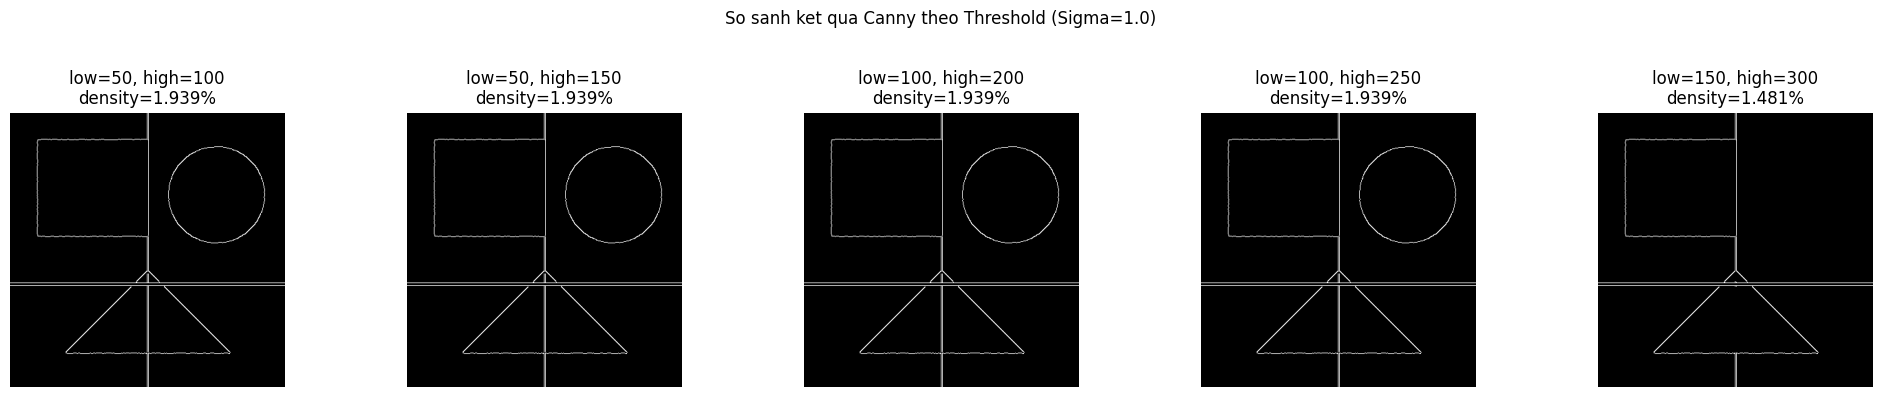

In [6]:
fig, axes = plt.subplots(1, len(threshold_results), figsize=(4 * len(threshold_results), 4))
for ax, r in zip(axes, threshold_results):
    ax.imshow(r["edges"], cmap="gray")
    ax.set_title(f"low={r['low_threshold']}, high={r['high_threshold']}\ndensity={r['edge_density_percent']}%")
    ax.axis("off")
fig.suptitle("So sanh ket qua Canny theo Threshold (Sigma=1.0)")
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


## 5. Biểu đồ xu hướng (Trend Line)

Sử dụng lại các hàm vẽ đường xu hướng từ
`src/visualization/plot_comparison.py` để quan sát rõ hơn mối quan hệ
giữa tham số và mật độ biên (edge density).


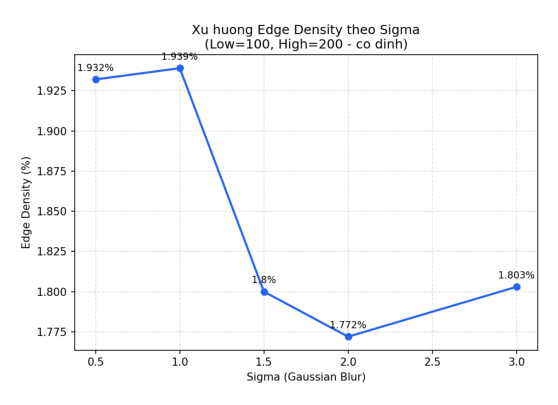

In [7]:
import tempfile

with tempfile.TemporaryDirectory() as tmp_dir:
    sigma_trend_path = Path(tmp_dir) / "sigma_trend.png"
    plot_sigma_trend_line(sigma_results, sigma_trend_path)
    plt.figure(figsize=(7, 5))
    plt.imshow(plt.imread(sigma_trend_path))
    plt.axis("off")
    plt.show()


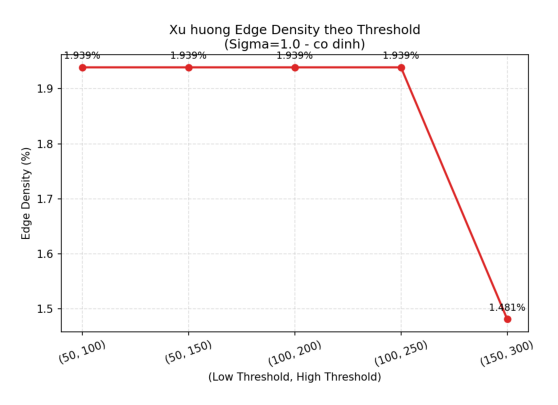

In [8]:
with tempfile.TemporaryDirectory() as tmp_dir:
    threshold_trend_path = Path(tmp_dir) / "threshold_trend.png"
    plot_threshold_trend_line(threshold_results, threshold_trend_path)
    plt.figure(figsize=(7, 5))
    plt.imshow(plt.imread(threshold_trend_path))
    plt.axis("off")
    plt.show()


## 6. Lưu kết quả

Ghi toàn bộ số liệu ra `results/tables/parameter_results.csv` và các
biểu đồ so sánh ra `results/figures/` — trùng với kết quả khi chạy
`python -m src.experiments.parameter_experiment`, để đảm bảo notebook
và script luôn nhất quán.


In [9]:
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

save_sigma_comparison_figure(sigma_results, FIGURES_DIR / "sigma_comparison.png")
save_results_table(sigma_results, threshold_results, TABLES_DIR / "parameter_results.csv")

print("Da luu ket qua vao thu muc results/.")


Da luu ket qua vao thu muc results/.


## 7. Nhận xét tổng hợp

In [10]:
print(summarize_sigma_trend(sigma_results))
print(summarize_threshold_trend(threshold_results))


Sigma tu 0.5 den 3.0: mat do bien tu 1.932% xuong 1.803% - khi Sigma tang, anh bi lam mo manh hon, cac chi tiet nho va nhieu bi trieu tieu nen mat do bien phat hien duoc giam dan.
Threshold tu (50, 100) den (150, 300): mat do bien tu 1.939% xuong 1.481% - threshold cang cao, Canny cang loai bo nhieu canh yeu, chi giu lai cac canh manh.


### Trả lời các câu hỏi bắt buộc của đề bài

| Câu hỏi | Trả lời |
|---|---|
| **Sigma tăng → ?** | Ảnh mờ hơn, nhiễu/chi tiết nhỏ bị loại bỏ tốt hơn, nhưng cạnh trở nên "trơn" và có thể mất cạnh mảnh. Mật độ biên có xu hướng **giảm**. |
| **Sigma giảm → ?** | Giữ nhiều chi tiết, cạnh sắc nét hơn, nhưng dễ sinh cạnh giả do nhiễu. Mật độ biên có xu hướng **tăng**. |
| **Low threshold tăng → ?** | Ít biên yếu được xét duyệt hơn → cạnh đứt đoạn nhiều hơn, mật độ biên **giảm**. |
| **Low threshold giảm → ?** | Nhiều biên yếu được chấp nhận hơn → mật độ biên **tăng**, dễ lẫn nhiễu. |
| **High threshold tăng → ?** | Tiêu chuẩn nhận biên mạnh khắt khe hơn → tổng số biên phát hiện được **giảm**. |
| **High threshold giảm → ?** | Nhiều pixel được công nhận là biên mạnh hơn → mật độ biên **tăng**, độ tin cậy từng biên giảm. |

Phân tích chi tiết và số liệu đầy đủ xem thêm tại:
`docs/06_results/parameter_comparison.md`.
